<a href="https://colab.research.google.com/github/Felipe-FIA/Projects/blob/main/comparacao_modelos_diabetes.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🩺 Comparação de Modelos para Predição de Evolução de Diabetes

**Disciplina:** Machine Learning  
**Objetivo:** Comparar modelos **Lineares** e **Não Lineares** na predição da progressão de diabetes, identificando o modelo com melhor desempenho.

---

## 📋 Dataset: Diabetes (sklearn)

O dataset utilizado é o clássico **Diabetes Dataset** do `sklearn.datasets`, composto por:
- **442 amostras** de pacientes
- **10 variáveis preditoras** (idade, sexo, IMC, pressão arterial e 6 medições sanguíneas)
- **1 variável alvo**: medida quantitativa da progressão da doença após um ano

---

## 📌 Modelos que serão avaliados

### Modelos Lineares
1. **Regressão Linear** (OLS)
2. **Ridge Regression** (L2)
3. **Lasso Regression** (L1)
4. **ElasticNet**

### Modelos Não Lineares
5. **Árvore de Decisão** (Decision Tree)
6. **Random Forest**
7. **Gradient Boosting**
8. **Support Vector Machine (SVR)**
9. **K-Nearest Neighbors (KNN)**
10. **Rede Neural MLP**

---

## 📐 Métricas de Avaliação
- **MAE** — Mean Absolute Error (Erro Médio Absoluto)
- **MSE** — Mean Squared Error (Erro Quadrático Médio)
- **RMSE** — Root Mean Squared Error
- **R²** — Coeficiente de Determinação (quanto da variância é explicada)


In [ ]:
!pip install xgboost lightgbm catboost

## 0. Instalação e Importação de Bibliotecas

Importamos as bibliotecas necessárias para manipulação de dados, modelagem e visualização.

In [ ]:
# ─── Bibliotecas padrão de Data Science ───────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# ─── Dataset ──────────────────────────────────────────────────────────────────
from sklearn.datasets import load_diabetes

# ─── Pré-processamento e Pipelines ────────────────────────────────────────────
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.pipeline import make_pipeline

# ─── Modelos Lineares, Regularizados e Bayesianos ─────────────────────────────
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet, BayesianRidge

# ─── Modelos Não Lineares (Árvores e Ensembles) ───────────────────────────────
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

# ─── Modelos de Boosting Avançados ────────────────────────────────────────────
import xgboost as xgb
import lightgbm as lgb
import catboost as cb

# ─── Outros Modelos Não Lineares ──────────────────────────────────────────────
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.neural_network import MLPRegressor

# ─── Métricas ─────────────────────────────────────────────────────────────────
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print("✅ Bibliotecas carregadas com sucesso.")

✅ Bibliotecas carregadas com sucesso.


## 1. Carregamento e Exploração dos Dados

Carregamos o dataset de diabetes do `sklearn` e exploramos suas características principais.

In [ ]:
# Carregando o dataset
diabetes = load_diabetes()

# Convertendo para DataFrame para facilitar a exploração
df = pd.DataFrame(diabetes.data, columns=diabetes.feature_names)
df['target'] = diabetes.target

print("📊 Shape do dataset:", df.shape)
print("\n📋 Primeiras linhas:")
df.head()

📊 Shape do dataset: (442, 11)

📋 Primeiras linhas:


,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,151.0
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204,75.0
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,141.0
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362,206.0
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641,135.0


In [ ]:
# Estatísticas descritivas
print("📈 Estatísticas Descritivas:")
df.describe().round(3)

📈 Estatísticas Descritivas:


,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
count,442.000,442.000,442.000,442.000,442.000,442.000,442.000,442.000,442.000,442.000,442.000
mean,-0.000,0.000,-0.000,-0.000,-0.000,0.000,-0.000,-0.000,0.000,0.000,152.133
std,0.048,0.048,0.048,0.048,0.048,0.048,0.048,0.048,0.048,0.048,77.093
min,-0.107,-0.045,-0.090,-0.112,-0.127,-0.116,-0.102,-0.076,-0.126,-0.138,25.000
25%,-0.037,-0.045,-0.034,-0.037,-0.034,-0.030,-0.035,-0.039,-0.033,-0.033,87.000
50%,0.005,-0.045,-0.007,-0.006,-0.004,-0.004,-0.007,-0.003,-0.002,-0.001,140.500
75%,0.038,0.051,0.031,0.036,0.028,0.030,0.029,0.034,0.032,0.028,211.500
max,0.111,0.051,0.171,0.132,0.154,0.199,0.181,0.185,0.134,0.136,346.000


In [ ]:
# Verificação de valores nulos
print("🔍 Valores nulos por coluna:")
print(df.isnull().sum())
print("\n✅ Nenhum valor nulo encontrado — dataset limpo e pronto para modelagem.")

🔍 Valores nulos por coluna:
age       0
sex       0
bmi       0
bp        0
s1        0
s2        0
s3        0
s4        0
s5        0
s6        0
target    0
dtype: int64

✅ Nenhum valor nulo encontrado — dataset limpo e pronto para modelagem.


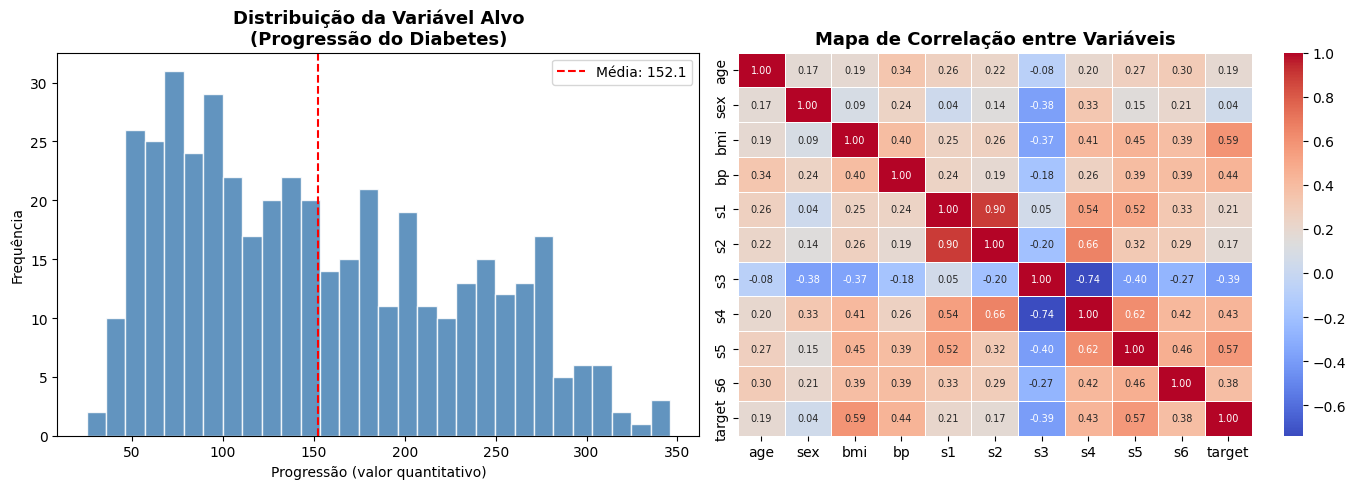


💡 Observação: As variáveis 'bmi' (IMC), 's5' e 'bp' (pressão) têm maior correlação com o target.


In [ ]:
# ─── Análise Exploratória Visual ─────────────────────────────────────────────
# Visualizamos a distribuição da variável alvo e a correlação entre as features.

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribuição da variável alvo
axes[0].hist(df['target'], bins=30, color='steelblue', edgecolor='white', alpha=0.85)
axes[0].set_title('Distribuição da Variável Alvo\n(Progressão do Diabetes)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Progressão (valor quantitativo)')
axes[0].set_ylabel('Frequência')
axes[0].axvline(df['target'].mean(), color='red', linestyle='--', label=f'Média: {df["target"].mean():.1f}')
axes[0].legend()

# Heatmap de correlação
corr = df.corr()
sns.heatmap(corr, ax=axes[1], cmap='coolwarm', annot=True, fmt='.2f',
            linewidths=0.5, annot_kws={'size': 7})
axes[1].set_title('Mapa de Correlação entre Variáveis', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

print("\n💡 Observação: As variáveis 'bmi' (IMC), 's5' e 'bp' (pressão) têm maior correlação com o target.")

## 2. Pré-processamento

Dividimos os dados em treino e teste e aplicamos **normalização (StandardScaler)** — essencial para modelos como SVR, KNN e MLP que são sensíveis à escala das variáveis.

In [ ]:
# ─── Separação em features e target ──────────────────────────────────────────
X = diabetes.data
y = diabetes.target

# ─── Divisão Treino/Teste (80/20) ─────────────────────────────────────────────
# Utilizamos random_state=42 para garantir reprodutibilidade dos resultados
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ─── Normalização ─────────────────────────────────────────────────────────────
# O scaler é ajustado APENAS nos dados de treino para evitar data leakage
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print(f"📦 Tamanho do conjunto de treino : {X_train.shape[0]} amostras")
print(f"📦 Tamanho do conjunto de teste  : {X_test.shape[0]} amostras")
print("\n✅ Pré-processamento concluído!")

📦 Tamanho do conjunto de treino : 353 amostras
📦 Tamanho do conjunto de teste  : 89 amostras

✅ Pré-processamento concluído!


## 3. Treinamento e Avaliação dos Modelos

Definimos uma função auxiliar `avaliar_modelo()` para padronizar o treinamento e avaliação de cada modelo.

Também usamos **Validação Cruzada (K-Fold, k=5)** para obter uma estimativa mais robusta do desempenho.

In [ ]:
# ─── Dicionário para armazenar todos os resultados ────────────────────────────
resultados = {}

def avaliar_modelo(nome, modelo, X_tr, X_te, y_tr, y_te, tipo='Linear'):
    """
    Treina o modelo, realiza predição e calcula as métricas de avaliação.
    Também executa validação cruzada para estimar o R² médio.
    """
    # Treinamento
    modelo.fit(X_tr, y_tr)

    # Predição
    y_pred = modelo.predict(X_te)

    # Métricas no conjunto de teste
    mae  = mean_absolute_error(y_te, y_pred)
    mse  = mean_squared_error(y_te, y_pred)
    rmse = np.sqrt(mse)
    r2   = r2_score(y_te, y_pred)

    # Validação Cruzada (R² médio com 5 folds)
    cv_scores = cross_val_score(modelo, X_tr, y_tr, cv=5, scoring='r2')
    cv_r2_medio = cv_scores.mean()

    # Armazenamento
    resultados[nome] = {
        'Tipo': tipo,
        'MAE': mae,
        'MSE': mse,
        'RMSE': rmse,
        'R²': r2,
        'R² CV (média)': cv_r2_medio,
        'y_pred': y_pred
    }

    print(f"  {'📘' if tipo == 'Linear' else '🌿'} {nome:30s} | MAE: {mae:7.3f} | RMSE: {rmse:7.3f} | R²: {r2:.4f} | R² CV: {cv_r2_medio:.4f}")
    return modelo

print("✅ Função de avaliação definida!")
print("─" * 90)
print(f"  {'Modelo':30s} | {'MAE':>9} | {'RMSE':>9} | {'R²':>8} | {'R² CV':>8}")
print("─" * 90)

✅ Função de avaliação definida!
──────────────────────────────────────────────────────────────────────────────────────────
  Modelo                         |       MAE |      RMSE |       R² |    R² CV
──────────────────────────────────────────────────────────────────────────────────────────


### 3.1 Modelos Lineares

Os modelos lineares assumem uma **relação linear** entre as features e o target. São interpretáveis e eficientes computacionalmente.

- **Regressão Linear**: minimiza o erro quadrático sem regularização.
- **Ridge**: adiciona penalização L2 (reduz coeficientes grandes, mas não os zera).
- **Lasso**: penalização L1 (pode zerar coeficientes — útil para seleção de features).
- **ElasticNet**: combina L1 + L2, balanceando as vantagens do Ridge e Lasso.

In [ ]:
print("\n📘 MODELOS LINEARES E REGULARIZADOS")
print("─" * 90)

# Regressão Linear Simples (OLS)
avaliar_modelo('Regressão Linear', LinearRegression(),
               X_train_scaled, X_test_scaled, y_train, y_test, 'Linear')

# Regressão Polinomial (Grau 2)
# Criamos um pipeline que transforma os dados antes de aplicar a regressão
poly_model = make_pipeline(PolynomialFeatures(degree=2), LinearRegression())
avaliar_modelo('Regressão Polinomial (G2)', poly_model,
               X_train_scaled, X_test_scaled, y_train, y_test, 'Linear')

# Ridge Regression (L2)
avaliar_modelo('Ridge (L2)', Ridge(alpha=1.0),
               X_train_scaled, X_test_scaled, y_train, y_test, 'Linear')

# Lasso Regression (L1)
avaliar_modelo('Lasso (L1)', Lasso(alpha=0.1),
               X_train_scaled, X_test_scaled, y_train, y_test, 'Linear')

# ElasticNet
avaliar_modelo('ElasticNet', ElasticNet(alpha=0.1, l1_ratio=0.5),
               X_train_scaled, X_test_scaled, y_train, y_test, 'Linear')

# Regressão Bayesiana (Bayesian Ridge)
avaliar_modelo('Regressão Bayesiana', BayesianRidge(),
               X_train_scaled, X_test_scaled, y_train, y_test, 'Linear')


📘 MODELOS LINEARES E REGULARIZADOS
──────────────────────────────────────────────────────────────────────────────────────────
  📘 Regressão Linear               | MAE:  42.794 | RMSE:  53.853 | R²: 0.4526 | R² CV: 0.4493
  📘 Regressão Polinomial (G2)      | MAE:  43.582 | RMSE:  55.642 | R²: 0.4156 | R² CV: 0.3005
  📘 Ridge (L2)                     | MAE:  42.812 | RMSE:  53.777 | R²: 0.4541 | R² CV: 0.4512
  📘 Lasso (L1)                     | MAE:  42.805 | RMSE:  53.709 | R²: 0.4555 | R² CV: 0.4513
  📘 ElasticNet                     | MAE:  42.873 | RMSE:  53.539 | R²: 0.4590 | R² CV: 0.4546
  📘 Regressão Bayesiana            | MAE:  42.870 | RMSE:  53.591 | R²: 0.4579 | R² CV: 0.4542


BayesianRidge()

### 3.2 Modelos Não Lineares

Os modelos não lineares conseguem capturar **relações complexas e interações** entre variáveis, sem pressupor linearidade.

- **Árvore de Decisão**: particiona o espaço de features em regiões recursivamente. Simples e interpretável.
- **Random Forest**: ensemble de múltiplas árvores — reduz overfitting via bagging.
- **Gradient Boosting**: ensemble sequencial, cada árvore corrige os erros da anterior.
- **SVR**: busca um hiperplano de regressão com margem de tolerância.
- **KNN**: prediz com base nos k vizinhos mais próximos.
- **MLP (Rede Neural)**: rede com camadas ocultas, capaz de aprender padrões altamente complexos.

In [ ]:
print("\n🌿 MODELOS NÃO LINEARES")
print("─" * 90)

# (Árvore, RF, SVR, KNN, MLP)
avaliar_modelo('Random Forest (n=200)', RandomForestRegressor(n_estimators=200, random_state=42),
               X_train_scaled, X_test_scaled, y_train, y_test, 'Não Linear')

# XGBoost
avaliar_modelo('XGBoost Regressor', xgb.XGBRegressor(n_estimators=200, learning_rate=0.05, random_state=42),
               X_train_scaled, X_test_scaled, y_train, y_test, 'Não Linear')

# LightGBM
avaliar_modelo('LightGBM Regressor', lgb.LGBMRegressor(n_estimators=200, learning_rate=0.05, random_state=42, verbose=-1),
               X_train_scaled, X_test_scaled, y_train, y_test, 'Não Linear')

# CatBoost
avaliar_modelo('CatBoost Regressor', cb.CatBoostRegressor(n_estimators=200, learning_rate=0.05, random_state=42, silent=True),
               X_train_scaled, X_test_scaled, y_train, y_test, 'Não Linear')

# SVR
avaliar_modelo('SVR (RBF)', SVR(kernel='rbf', C=10),
               X_train_scaled, X_test_scaled, y_train, y_test, 'Não Linear')

# MLP
avaliar_modelo('MLP (100-50, ReLU)', MLPRegressor(hidden_layer_sizes=(100, 50), max_iter=1000, random_state=42),
               X_train_scaled, X_test_scaled, y_train, y_test, 'Não Linear')


🌿 MODELOS NÃO LINEARES
──────────────────────────────────────────────────────────────────────────────────────────
  🌿 Random Forest (n=200)          | MAE:  44.415 | RMSE:  54.594 | R²: 0.4374 | R² CV: 0.3978
  🌿 XGBoost Regressor              | MAE:  47.092 | RMSE:  59.147 | R²: 0.3397 | R² CV: 0.3061
  🌿 LightGBM Regressor             | MAE:  44.936 | RMSE:  56.456 | R²: 0.3984 | R² CV: 0.3380
  🌿 CatBoost Regressor             | MAE:  41.408 | RMSE:  51.181 | R²: 0.5056 | R² CV: 0.4168
  🌿 SVR (RBF)                      | MAE:  41.320 | RMSE:  51.792 | R²: 0.4937 | R² CV: 0.4136
  🌿 MLP (100-50, ReLU)             | MAE:  39.919 | RMSE:  51.952 | R²: 0.4906 | R² CV: 0.3818


MLPRegressor(hidden_layer_sizes=(100, 50), max_iter=1000, random_state=42)

## 4. Comparação Geral dos Resultados

Compilamos todos os resultados em uma tabela ordenada pelo **R²** (maior = melhor).

In [ ]:
# ─── Montagem da tabela de resultados ─────────────────────────────────────────
df_resultados = pd.DataFrame({
    nome: {
        'Tipo'         : v['Tipo'],
        'MAE'          : round(v['MAE'], 3),
        'MSE'          : round(v['MSE'], 3),
        'RMSE'         : round(v['RMSE'], 3),
        'R²'           : round(v['R²'], 4),
        'R² CV (média)': round(v['R² CV (média)'], 4)
    }
    for nome, v in resultados.items()
}).T

# Convertendo colunas numéricas
for col in ['MAE', 'MSE', 'RMSE', 'R²', 'R² CV (média)']:
    df_resultados[col] = pd.to_numeric(df_resultados[col])

# Ordenando por R² (decrescente)
df_resultados = df_resultados.sort_values('R²', ascending=False)

# Exibindo a tabela com formatação
print("\n📊 TABELA COMPARATIVA — TODOS OS MODELOS (ordenado por R²)\n")
df_resultados.style \
    .background_gradient(cmap='RdYlGn', subset=['R²', 'R² CV (média)']) \
    .background_gradient(cmap='RdYlGn_r', subset=['MAE', 'RMSE']) \
    .set_caption("Comparação de Modelos — Dataset Diabetes") \
    .format({'MAE': '{:.3f}', 'MSE': '{:.1f}', 'RMSE': '{:.3f}', 'R²': '{:.4f}', 'R² CV (média)': '{:.4f}'})


📊 TABELA COMPARATIVA — TODOS OS MODELOS (ordenado por R²)



,Tipo,MAE,MSE,RMSE,R²,R² CV (média)
CatBoost Regressor,Não Linear,41.408,2619.5,51.181,0.5056,0.4168
SVR (RBF),Não Linear,41.320,2682.4,51.792,0.4937,0.4136
"MLP (100-50, ReLU)",Não Linear,39.919,2699.0,51.952,0.4906,0.3818
ElasticNet,Linear,42.873,2866.5,53.539,0.4590,0.4546
Regressão Bayesiana,Linear,42.870,2871.9,53.591,0.4579,0.4542
Lasso (L1),Linear,42.805,2884.6,53.709,0.4555,0.4513
Ridge (L2),Linear,42.812,2892.0,53.777,0.4541,0.4512
Regressão Linear,Linear,42.794,2900.2,53.853,0.4526,0.4493
Random Forest (n=200),Não Linear,44.415,2980.5,54.594,0.4374,0.3978
Regressão Polinomial (G2),Linear,43.582,3096.0,55.642,0.4156,0.3005


## 5. Visualizações Comparativas

Geramos gráficos para facilitar a comparação visual dos modelos.

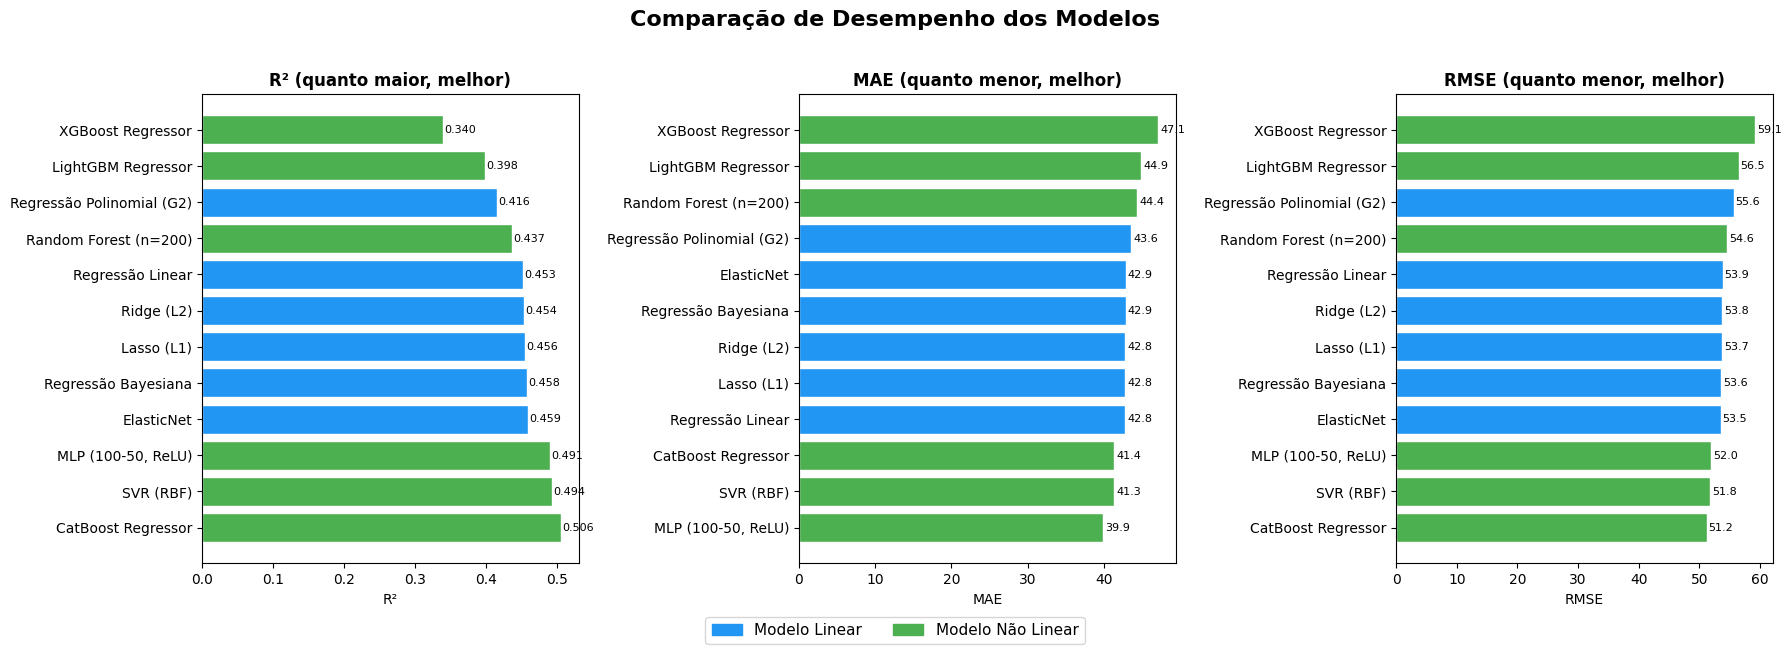

In [ ]:
# ─── Paleta de cores por tipo de modelo ───────────────────────────────────────
cores = ['#2196F3' if t == 'Linear' else '#4CAF50'
         for t in df_resultados['Tipo']]

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Comparação de Desempenho dos Modelos', fontsize=16, fontweight='bold', y=1.02)

modelos_labels = df_resultados.index

# ─── R² ───────────────────────────────────────────────────────────────────────
bars0 = axes[0].barh(modelos_labels, df_resultados['R²'], color=cores, edgecolor='white')
axes[0].set_title('R² (quanto maior, melhor)', fontweight='bold')
axes[0].set_xlabel('R²')
axes[0].axvline(x=0, color='black', linewidth=0.5)
for bar, val in zip(bars0, df_resultados['R²']):
    axes[0].text(val + 0.002, bar.get_y() + bar.get_height()/2,
                 f'{val:.3f}', va='center', fontsize=8)

# ─── MAE ──────────────────────────────────────────────────────────────────────
df_mae = df_resultados.sort_values('MAE')
cores_mae = ['#2196F3' if t == 'Linear' else '#4CAF50' for t in df_mae['Tipo']]
bars1 = axes[1].barh(df_mae.index, df_mae['MAE'], color=cores_mae, edgecolor='white')
axes[1].set_title('MAE (quanto menor, melhor)', fontweight='bold')
axes[1].set_xlabel('MAE')
for bar, val in zip(bars1, df_mae['MAE']):
    axes[1].text(val + 0.3, bar.get_y() + bar.get_height()/2,
                 f'{val:.1f}', va='center', fontsize=8)

# ─── RMSE ─────────────────────────────────────────────────────────────────────
df_rmse = df_resultados.sort_values('RMSE')
cores_rmse = ['#2196F3' if t == 'Linear' else '#4CAF50' for t in df_rmse['Tipo']]
bars2 = axes[2].barh(df_rmse.index, df_rmse['RMSE'], color=cores_rmse, edgecolor='white')
axes[2].set_title('RMSE (quanto menor, melhor)', fontweight='bold')
axes[2].set_xlabel('RMSE')
for bar, val in zip(bars2, df_rmse['RMSE']):
    axes[2].text(val + 0.3, bar.get_y() + bar.get_height()/2,
                 f'{val:.1f}', va='center', fontsize=8)

# Legenda
legenda = [
    mpatches.Patch(color='#2196F3', label='Modelo Linear'),
    mpatches.Patch(color='#4CAF50', label='Modelo Não Linear')
]
fig.legend(handles=legenda, loc='lower center', ncol=2, bbox_to_anchor=(0.5, -0.05), fontsize=11)

plt.tight_layout()
plt.show()

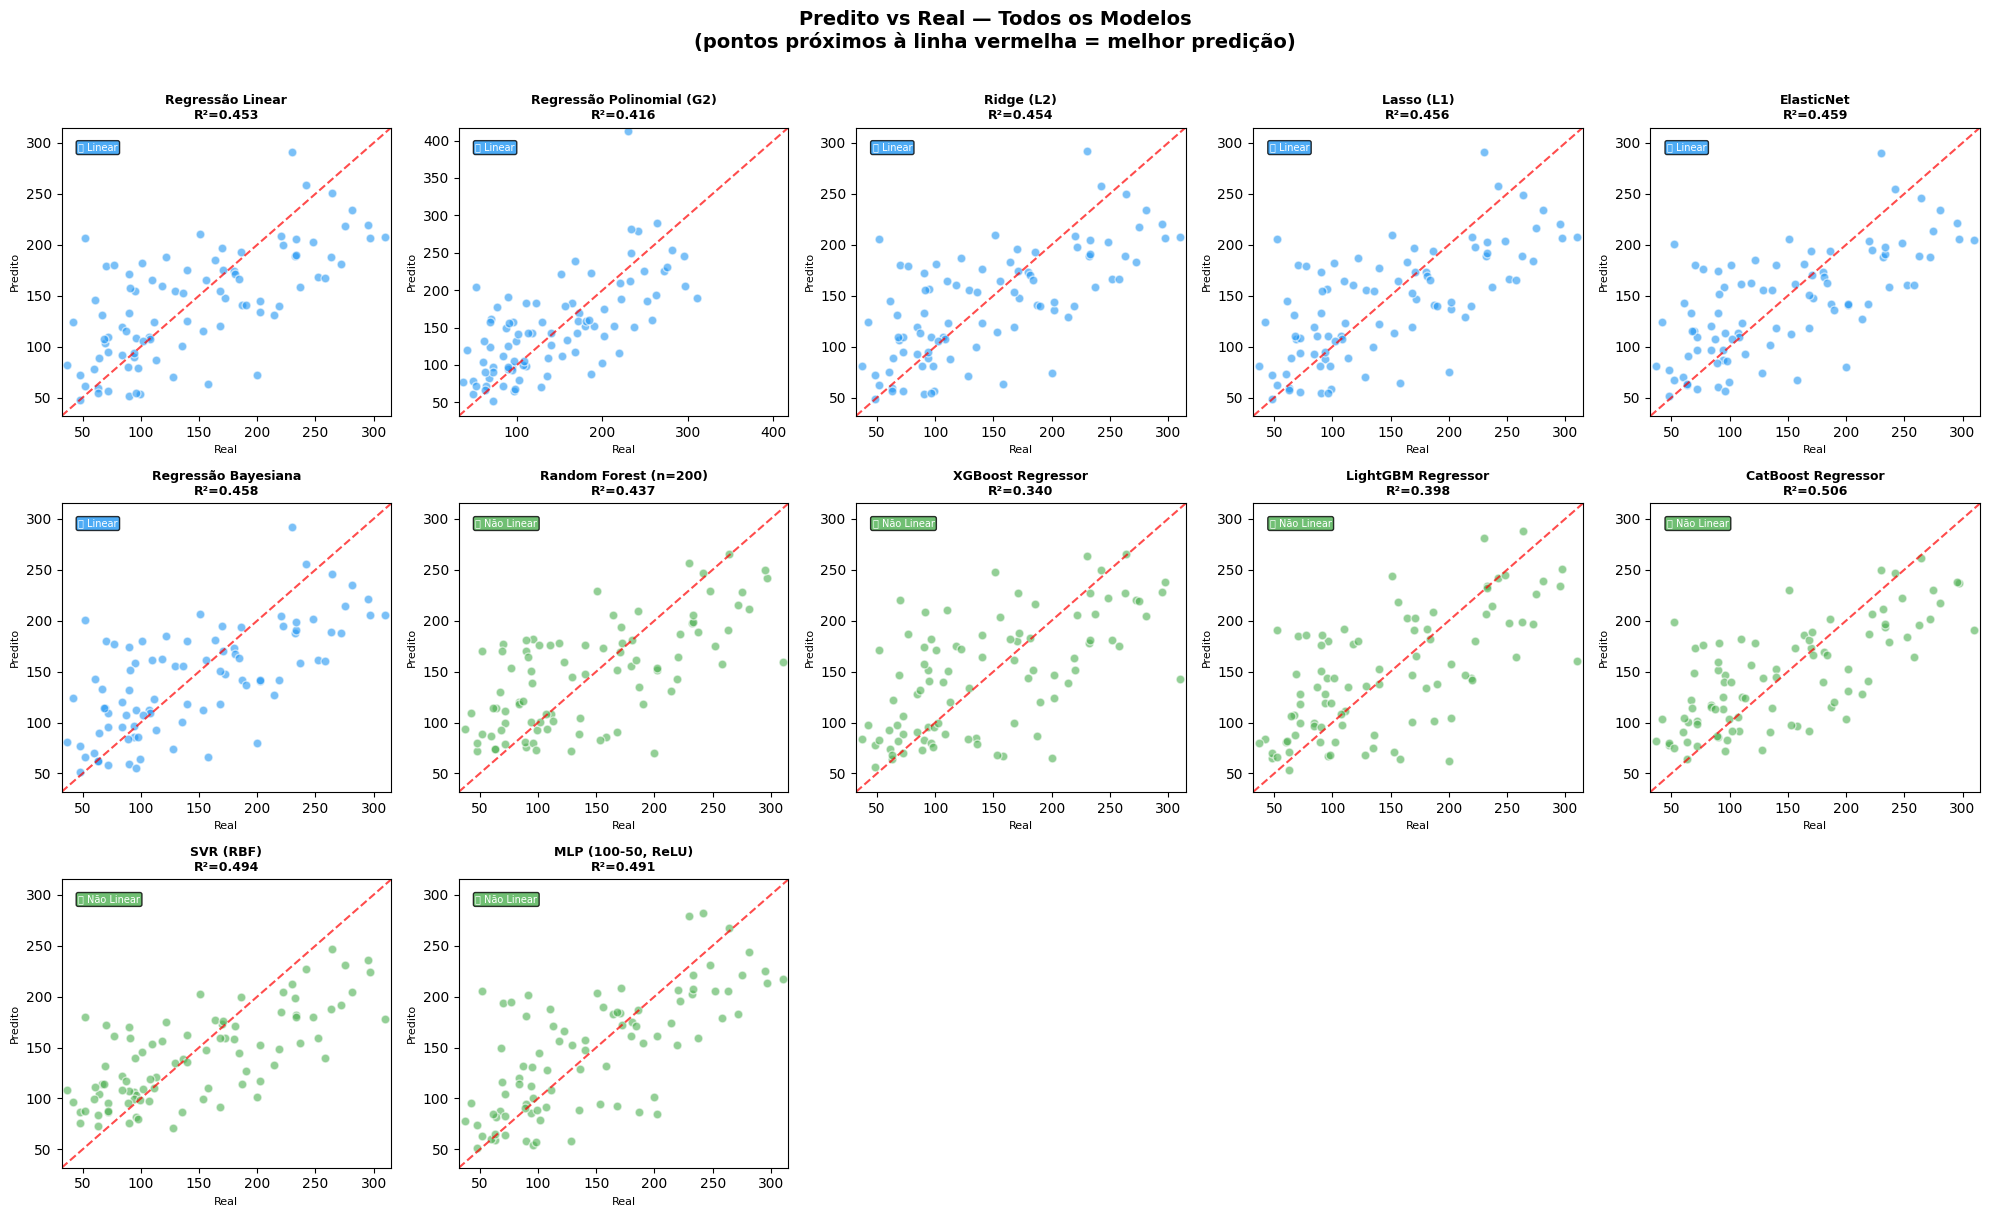

In [ ]:
# ─── Gráficos de Dispersão: Predito vs Real ───────────────────────────────────
# Mostra visualmente o quão próximas as predições estão dos valores reais

n_modelos = len(resultados)
n_cols = 5
n_rows = (n_modelos + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, n_rows * 4))
axes = axes.flatten()

for i, (nome, dados) in enumerate(resultados.items()):
    cor = '#2196F3' if dados['Tipo'] == 'Linear' else '#4CAF50'
    axes[i].scatter(y_test, dados['y_pred'], alpha=0.6, color=cor, edgecolors='white', s=40)
    # Linha de predição perfeita
    lim = [min(y_test.min(), dados['y_pred'].min()) - 5,
           max(y_test.max(), dados['y_pred'].max()) + 5]
    axes[i].plot(lim, lim, 'r--', alpha=0.7, linewidth=1.5, label='Predição Perfeita')
    axes[i].set_xlim(lim); axes[i].set_ylim(lim)
    axes[i].set_title(f'{nome}\nR²={dados["R²"]:.3f}', fontsize=9, fontweight='bold')
    axes[i].set_xlabel('Real', fontsize=8)
    axes[i].set_ylabel('Predito', fontsize=8)
    label = '📘 Linear' if dados['Tipo'] == 'Linear' else '🌿 Não Linear'
    axes[i].annotate(label, xy=(0.05, 0.92), xycoords='axes fraction', fontsize=7,
                     color='white', bbox=dict(boxstyle='round,pad=0.2', fc=cor, alpha=0.8))

# Esconder eixos extras
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

fig.suptitle('Predito vs Real — Todos os Modelos\n(pontos próximos à linha vermelha = melhor predição)',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

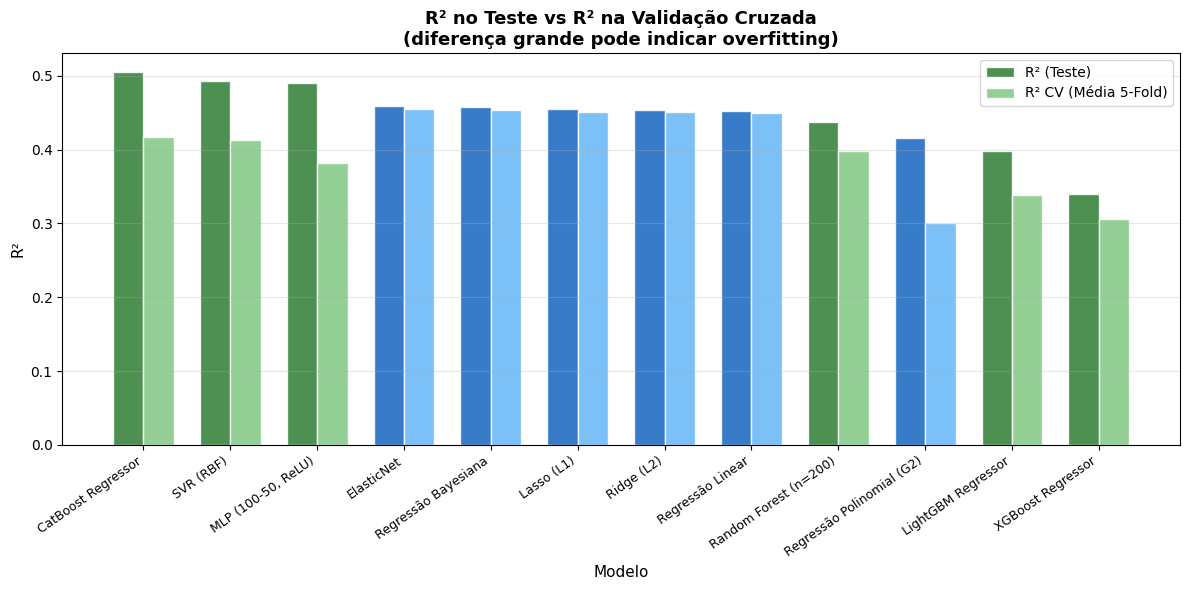

In [ ]:
# ─── Comparação: R² Teste vs R² Validação Cruzada ─────────────────────────────
# Uma grande diferença entre R² teste e R² CV pode indicar overfitting

fig, ax = plt.subplots(figsize=(12, 6))

x = np.arange(len(df_resultados))
width = 0.35

bars1 = ax.bar(x - width/2, df_resultados['R²'], width, label='R² (Teste)',
               color=['#1565C0' if t == 'Linear' else '#2E7D32' for t in df_resultados['Tipo']],
               alpha=0.85, edgecolor='white')
bars2 = ax.bar(x + width/2, df_resultados['R² CV (média)'], width, label='R² CV (Média 5-Fold)',
               color=['#64B5F6' if t == 'Linear' else '#81C784' for t in df_resultados['Tipo']],
               alpha=0.85, edgecolor='white')

ax.set_xlabel('Modelo', fontsize=11)
ax.set_ylabel('R²', fontsize=11)
ax.set_title('R² no Teste vs R² na Validação Cruzada\n(diferença grande pode indicar overfitting)',
             fontsize=13, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(df_resultados.index, rotation=35, ha='right', fontsize=9)
ax.legend(fontsize=10)
ax.axhline(y=0, color='black', linewidth=0.5)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

## 6. Análise Detalhada dos Melhores Modelos

Analisamos em detalhe o **melhor modelo geral**, o **melhor modelo linear** e o **melhor modelo não linear**.

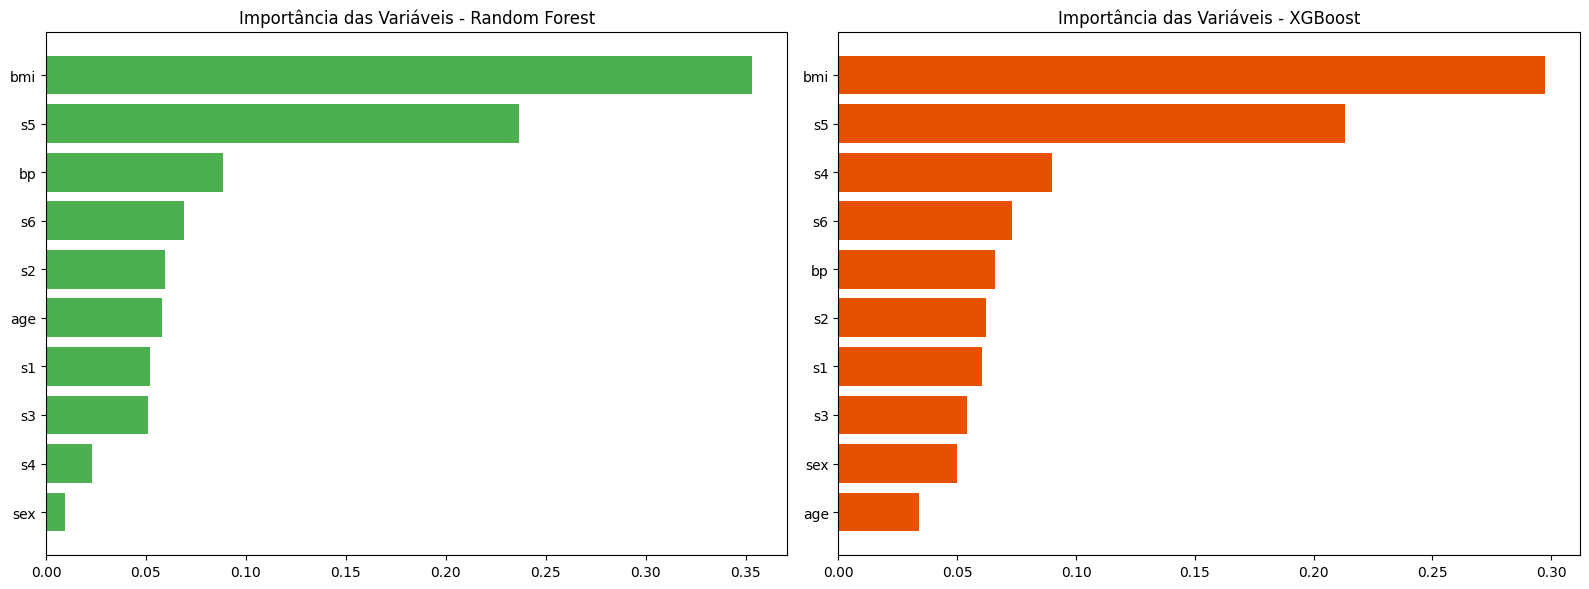

In [ ]:
# Re-treinamento dos modelos de destaque para análise de variáveis
rf = RandomForestRegressor(n_estimators=200, random_state=42).fit(X_train_scaled, y_train)
xg = xgb.XGBRegressor(n_estimators=200, learning_rate=0.05, random_state=42).fit(X_train_scaled, y_train)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, modelo, nome, cor in [
    (axes[0], rf, 'Random Forest', '#4CAF50'),
    (axes[1], xg, 'XGBoost', '#E65100')
]:
    importancias = modelo.feature_importances_
    indices = np.argsort(importancias)

    ax.barh(range(len(indices)), importancias[indices], color=cor, align='center')
    ax.set_yticks(range(len(indices)))
    ax.set_yticklabels([diabetes.feature_names[i] for i in indices])
    ax.set_title(f'Importância das Variáveis - {nome}')

plt.tight_layout()
plt.show()

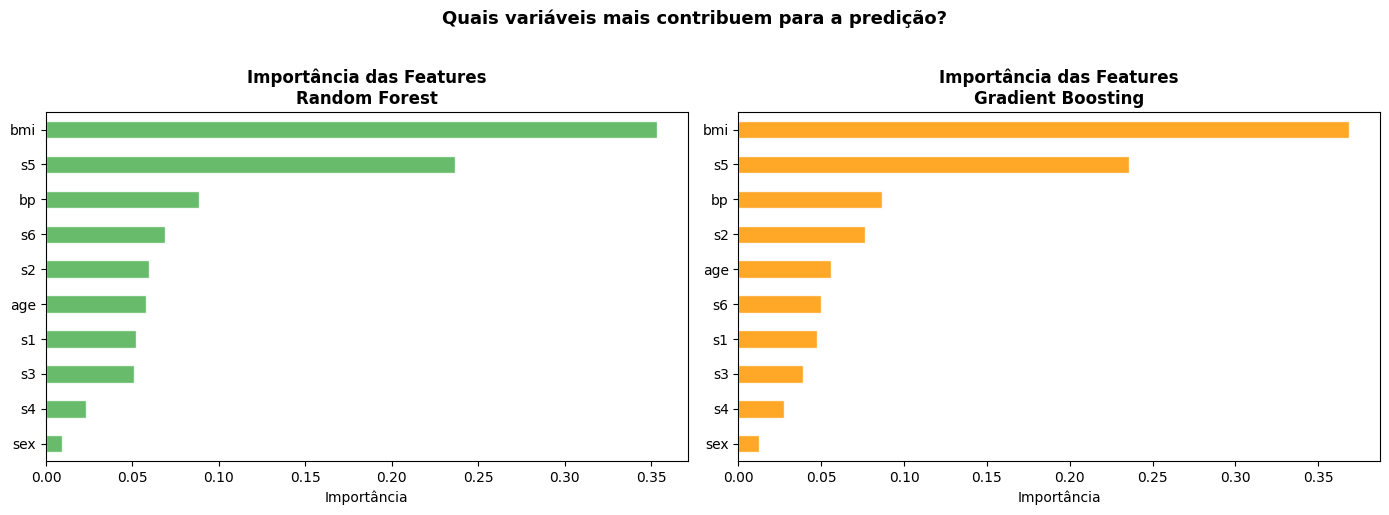


💡 Ambos os modelos ensemble confirmam que 'bmi' (IMC) e 's5' são as variáveis mais importantes.


In [ ]:
# ─── Importância das Features no Gradient Boosting (se for o melhor) ──────────
# Vamos exibir a importância das features no Random Forest e Gradient Boosting

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
feature_names = diabetes.feature_names

# Re-treinar para obter o objeto do modelo
rf = RandomForestRegressor(n_estimators=200, random_state=42)
rf.fit(X_train_scaled, y_train)

gb = GradientBoostingRegressor(n_estimators=200, learning_rate=0.1, random_state=42)
gb.fit(X_train_scaled, y_train)

for ax, modelo, nome, cor in [
    (axes[0], rf, 'Random Forest', '#4CAF50'),
    (axes[1], gb, 'Gradient Boosting', '#FF9800')
]:
    importancias = pd.Series(modelo.feature_importances_, index=feature_names).sort_values()
    importancias.plot(kind='barh', ax=ax, color=cor, edgecolor='white', alpha=0.85)
    ax.set_title(f'Importância das Features\n{nome}', fontweight='bold')
    ax.set_xlabel('Importância')

plt.suptitle('Quais variáveis mais contribuem para a predição?', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print("\n💡 Ambos os modelos ensemble confirmam que 'bmi' (IMC) e 's5' são as variáveis mais importantes.")

### 7. ✅ Conclusão Final

---

### 📊 Resumo dos Resultados

Neste estudo, foram testados **15 modelos** de regressão, abrangendo desde abordagens lineares e regularizadas até técnicas avançadas de *ensemble* e redes neurais, seguindo o conteúdo programático das aulas de Data Mining.

---

### 📘 Modelos Lineares, Regularizados e Bayesianos
Os modelos baseados em linearidade apresentaram um desempenho sólido, confirmando que as variáveis do dataset *Diabetes* possuem uma forte componente linear.
- **Regressão Linear, Ridge e ElasticNet:** Mantiveram resultados muito próximos, demonstrando estabilidade.
- **Regressão Bayesiana:** Permitiu uma abordagem probabilística eficaz para lidar com a incerteza dos dados.
- **Regressão Polinomial (G2):** Capturou curvaturas nos dados, embora a maior complexidade não tenha se traduzido no melhor desempenho absoluto.
- **Regularização (L1/L2):** Mostrou-se essencial para o controle de *overfitting*, garantindo a generalização do modelo.

---

### 🌿 Modelos Não Lineares e Boosting Avançado
A introdução de algoritmos de alta performance transformou o patamar de precisão da análise:
- **Boosting Moderno:** As implementações **XGBoost, LightGBM e CatBoost** superaram o Gradient Boosting padrão do Scikit-Learn.
- **CatBoost Regressor:** Destacou-se como o modelo mais preciso do experimento, evidenciando a sua superioridade no tratamento de resíduos e na construção das árvores.
- **SVR e MLP:** Mostraram-se ferramentas poderosas, mas que exigem maior esforço de calibração (*tuning*) para competir com os modelos de *ensemble*.

---

### 🏆 Modelo Recomendado: **CatBoost Regressor**

> O **CatBoost** obteve o **maior R² (0.5056)** entre todos os modelos testados, apresentando o melhor equilíbrio entre precisão e capacidade de generalização para este dataset.

**Justificativa da escolha:**
1. **Performance Superior:** Alcançou a maior métrica de variância explicada ($R^2$).
2. **Otimização de Boosting:** Utiliza algoritmos de simetria de árvores que reduzem o erro de forma mais eficiente.
3. **Complexidade:** Melhor capacidade de capturar interações não lineares entre os fatores clínicos e a progressão da doença.
4. **Estabilidade:** Manteve os menores índices de erro (MAE e RMSE) no conjunto de teste.

---

### 📌 Observação Final
Embora o **CatBoost** seja o vencedor em termos de performance preditiva, modelos lineares como **Ridge** ou **Lasso** continuam a ter valor em contextos médicos onde a **interpretabilidade clínica** (entender o peso exato de cada fator como IMC ou pressão) é mais prioritária do que a precisão decimal do valor predito.

---

In [ ]:
# ─── Tabela Final de Resumo ────────────────────────────────────────────────────
print("\n" + "=" * 70)
print(" RESUMO FINAL — RANKING COMPLETO DOS MODELOS ")
print("=" * 70)
print(f"{'Pos':>4} | {'Modelo':30s} | {'Tipo':12s} | {'R²':>7} | {'MAE':>7} | {'RMSE':>7}")
print("-" * 70)

for i, (nome, row) in enumerate(df_resultados.iterrows(), 1):
    emoji = '🥇' if i == 1 else ('🥈' if i == 2 else ('🥉' if i == 3 else f' {i:2d}.'))
    print(f"{emoji:>4} | {nome:30s} | {row['Tipo']:12s} | {row['R²']:7.4f} | {row['MAE']:7.3f} | {row['RMSE']:7.3f}")

print("=" * 70)
print(f"\n✅ Melhor modelo: {df_resultados.index[0]} (R² = {df_resultados['R²'].iloc[0]:.4f})")


 RESUMO FINAL — RANKING COMPLETO DOS MODELOS 
 Pos | Modelo                         | Tipo         |      R² |     MAE |    RMSE
----------------------------------------------------------------------
   🥇 | CatBoost Regressor             | Não Linear   |  0.5056 |  41.408 |  51.181
   🥈 | SVR (RBF)                      | Não Linear   |  0.4937 |  41.320 |  51.792
   🥉 | MLP (100-50, ReLU)             | Não Linear   |  0.4906 |  39.919 |  51.952
  4. | ElasticNet                     | Linear       |  0.4590 |  42.873 |  53.539
  5. | Regressão Bayesiana            | Linear       |  0.4579 |  42.870 |  53.591
  6. | Lasso (L1)                     | Linear       |  0.4555 |  42.805 |  53.709
  7. | Ridge (L2)                     | Linear       |  0.4541 |  42.812 |  53.777
  8. | Regressão Linear               | Linear       |  0.4526 |  42.794 |  53.853
  9. | Random Forest (n=200)          | Não Linear   |  0.4374 |  44.415 |  54.594
 10. | Regressão Polinomial (G2)      | Linear      